# Data Cleaning

Subset of Kaggle H&M Dataset downloaded from: https://www.kaggle.com/datasets/sohyunjun0401/h-and-m-personalized-fashion-data/data

- Raw files save to `./data/raw`
- Cleaned files save to `./data/processed`

3 files: `articles_hm.csv`, `customer_hm.csv`, `transactions_hm.csv`

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

# Define paths
from pathlib import Path
base_path = Path("../data/")
raw_path = base_path / 'raw'
processed_path = base_path / 'processed'

# Initialize summary report
summary = {
    'articles': {},
    'customers': {},
    'transactions': {}
}

print("=" * 60)
print("DATA CLEANING REPORT - H&M Datasets")
print("=" * 60)
print(f"Cleaning started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 60)

DATA CLEANING REPORT - H&M Datasets
Cleaning started at: 2026-03-12 11:06:55


## Articles

Check for duplicates and missing values

Remove duplicates

Categorical data filled with "Unknown"

Missing numeric data drops the row

In [2]:
# ============================================================
# 1. CLEAN ARTICLES DATASET
# ============================================================
print("\n[1/3] CLEANING ARTICLES DATASET")
print("-" * 40)

articles = pd.read_csv(raw_path / "articles_hm.csv")
summary['articles']['original_rows'] = len(articles)
summary['articles']['original_cols'] = len(articles.columns)

print(f"Original shape: {articles.shape}")

# Check for duplicates
duplicates = articles.duplicated(subset=['article_id']).sum()
summary['articles']['duplicates_removed'] = duplicates
if duplicates > 0:
    articles = articles.drop_duplicates(subset=['article_id'], keep='first')
    print(f"Removed {duplicates} duplicate article_id rows")

# Check for missing values
missing_before = articles.isnull().sum().sum()
summary['articles']['missing_values_before'] = missing_before

# Handle missing values
# For categorical columns, fill with 'Unknown'
categorical_cols = articles.select_dtypes(include=['object']).columns
for col in categorical_cols:
    missing_count = articles[col].isnull().sum()
    if missing_count > 0:
        articles[col] = articles[col].fillna('Unknown')
        print(f"  Filled {missing_count} missing values in '{col}' with 'Unknown'")

# Check numeric columns for missing values
numeric_cols = articles.select_dtypes(include=[np.number]).columns
total_numeric_missing = 0
for col in numeric_cols:
    missing_count = articles[col].isnull().sum()
    total_numeric_missing += missing_count
print(f"  Found {total_numeric_missing} missing values in numeric columns")

summary['articles']['missing_values_after'] = articles.isnull().sum().sum()

# Ensure article_id is string and properly formatted
articles['article_id'] = articles['article_id'].astype(str).str.zfill(10)
articles['product_code'] = articles['product_code'].astype(str).str.zfill(7)

# Strip whitespace from string columns
for col in categorical_cols:
    if col in articles.columns:
        articles[col] = articles[col].str.strip()

summary['articles']['final_rows'] = len(articles)
print(f"Final shape: {articles.shape}")

# Save cleaned articles
articles.to_csv(processed_path / "articles_hm_cleaned.csv", index=False)
print("Saved: articles_hm_cleaned.csv")


[1/3] CLEANING ARTICLES DATASET
----------------------------------------
Original shape: (105542, 25)
  Filled 416 missing values in 'detail_desc' with 'Unknown'
  Found 0 missing values in numeric columns
Final shape: (105542, 25)
Saved: articles_hm_cleaned.csv


## Customers

Check for duplicates and missing values

Remove duplicates

Categorical data filled with "Unknown" or "NONE"

Missing numeric data drops the row
Age clipped for young (<10) or old (>100) values

In [3]:
# ============================================================
# 2. CLEAN CUSTOMERS DATASET
# ============================================================
print("\n[2/3] CLEANING CUSTOMERS DATASET")
print("-" * 40)

customers = pd.read_csv(raw_path / "customer_hm.csv")
summary['customers']['original_rows'] = len(customers)
summary['customers']['original_cols'] = len(customers.columns)

print(f"Original shape: {customers.shape}")

# Check for duplicates
duplicates = customers.duplicated(subset=['customer_id']).sum()
summary['customers']['duplicates_removed'] = duplicates
if duplicates > 0:
    customers = customers.drop_duplicates(subset=['customer_id'], keep='first')
    print(f"Removed {duplicates} duplicate customer_id rows")

# Check for missing values
missing_before = customers.isnull().sum().sum()
summary['customers']['missing_values_before'] = missing_before

# Handle missing values for each column appropriately
# FN and Active - binary columns, fill with mode (0)
for col in ['FN', 'Active']:
    missing_count = customers[col].isnull().sum()
    if missing_count > 0:
        customers[col] = customers[col].fillna(0).astype(int)
        print(f"  Filled {missing_count} missing values in '{col}' with 0")

# club_member_status - fill with 'Unknown'
if customers['club_member_status'].isnull().sum() > 0:
    missing_count = customers['club_member_status'].isnull().sum()
    customers['club_member_status'] = customers['club_member_status'].fillna('Unknown')
    print(f"  Filled {missing_count} missing values in 'club_member_status' with 'Unknown'")

# fashion_news_frequency - fill with 'NONE'
if customers['fashion_news_frequency'].isnull().sum() > 0:
    missing_count = customers['fashion_news_frequency'].isnull().sum()
    customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')
    print(f"  Filled {missing_count} missing values in 'fashion_news_frequency' with 'NONE'")

# age - check for missing values
missing_age = customers['age'].isnull().sum()
print(f"  Found {missing_age} missing values in 'age'")

# Handle age outliers (cap at reasonable bounds: 10-100)
age_outliers = ((customers['age'] < 10) | (customers['age'] > 100)).sum()
if age_outliers > 0:
    customers['age'] = customers['age'].clip(lower=10, upper=100)
    print(f"  Capped {age_outliers} age outliers to range [10, 100]")
    summary['customers']['age_outliers_fixed'] = age_outliers

summary['customers']['missing_values_after'] = customers.isnull().sum().sum()

# Standardize categorical values
customers['club_member_status'] = customers['club_member_status'].str.upper().str.strip()
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].str.upper().str.strip()

# Ensure proper data types
customers['FN'] = customers['FN'].astype(int)
customers['Active'] = customers['Active'].astype(int)
customers['age'] = customers['age'].astype(int)

summary['customers']['final_rows'] = len(customers)
print(f"Final shape: {customers.shape}")

# Save cleaned customers
customers.to_csv(processed_path / "customer_hm_cleaned.csv", index=False)
print("Saved: customer_hm_cleaned.csv")


[2/3] CLEANING CUSTOMERS DATASET
----------------------------------------
Original shape: (1048575, 6)
  Filled 1 missing values in 'fashion_news_frequency' with 'NONE'
  Found 0 missing values in 'age'
Final shape: (1048575, 6)
Saved: customer_hm_cleaned.csv


## Transactions

Remove all duplicates

Drop rows with missing values or invalid dates

Format ID and price data

In [4]:
# ============================================================
# 3. CLEAN TRANSACTIONS DATASET
# ============================================================
print("\n[3/3] CLEANING TRANSACTIONS DATASET")
print("-" * 40)

transactions = pd.read_csv(raw_path / "transactions_hm.csv")
summary['transactions']['original_rows'] = len(transactions)
summary['transactions']['original_cols'] = len(transactions.columns)

print(f"Original shape: {transactions.shape}")

# Check for duplicates (exact duplicates across all columns)
duplicates = transactions.duplicated().sum()
summary['transactions']['duplicates_removed'] = duplicates
if duplicates > 0:
    transactions = transactions.drop_duplicates(keep='first')
    print(f"Removed {duplicates} exact duplicate rows")

# Check for missing values
missing_before = transactions.isnull().sum().sum()
summary['transactions']['missing_values_before'] = missing_before

# Handle missing values
for col in transactions.columns:
    missing_count = transactions[col].isnull().sum()
    if missing_count > 0:
        print(f"  Found {missing_count} missing values in '{col}'")
        if col == 't_dat':
            transactions = transactions.dropna(subset=['t_dat'])
            print(f"    Dropped rows with missing dates")
        elif col == 'customer_id':
            transactions = transactions.dropna(subset=['customer_id'])
            print(f"    Dropped rows with missing customer_id")
        elif col == 'article_id':
            transactions = transactions.dropna(subset=['article_id'])
            print(f"    Dropped rows with missing article_id")
        elif col == 'price':
            transactions = transactions.dropna(subset=['price'])
            print(f"    Dropped rows with missing price")
        elif col == 'sales_channel_id':
            transactions = transactions.dropna(subset=['sales_channel_id'])
            print(f"    Dropped rows with missing sales_channel_id")

summary['transactions']['missing_values_after'] = transactions.isnull().sum().sum()

# Convert date column to datetime
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'], errors='coerce')

# Remove any rows where date conversion failed
invalid_dates = transactions['t_dat'].isnull().sum()
if invalid_dates > 0:
    transactions = transactions.dropna(subset=['t_dat'])
    print(f"Removed {invalid_dates} rows with invalid dates")
    summary['transactions']['invalid_dates_removed'] = invalid_dates

# Ensure article_id is properly formatted
transactions['article_id'] = transactions['article_id'].astype(str).str.zfill(10)

# Handle price outliers (remove negative or extremely high prices)
price_outliers = ((transactions['price'] < 0) | (transactions['price'] > 1)).sum()
if price_outliers > 0:
    transactions = transactions[(transactions['price'] >= 0) & (transactions['price'] <= 1)]
    print(f"Removed {price_outliers} rows with invalid prices (outside 0-1 range)")
    summary['transactions']['price_outliers_removed'] = price_outliers

# Ensure proper data types
transactions['sales_channel_id'] = transactions['sales_channel_id'].astype(int)
transactions['price'] = transactions['price'].astype(float)

summary['transactions']['final_rows'] = len(transactions)
print(f"Final shape: {transactions.shape}")

# Save cleaned transactions
transactions.to_csv(processed_path / "transactions_hm_cleaned.csv", index=False)
print("Saved: transactions_hm_cleaned.csv")



[3/3] CLEANING TRANSACTIONS DATASET
----------------------------------------
Original shape: (1048575, 5)
Removed 8474 exact duplicate rows
Final shape: (1040101, 5)
Saved: transactions_hm_cleaned.csv


In [5]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)

for dataset, stats in summary.items():
    print(f"\n{dataset.upper()}:")
    print(f"  Original rows: {stats.get('original_rows', 'N/A')}")
    print(f"  Final rows: {stats.get('final_rows', 'N/A')}")
    print(f"  Duplicates removed: {stats.get('duplicates_removed', 0)}")
    print(f"  Missing values (before): {stats.get('missing_values_before', 0)}")
    print(f"  Missing values (after): {stats.get('missing_values_after', 0)}")

print("\n" + "=" * 60)
print("CLEANING COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nCleaned files saved:")
print("  - articles_hm_cleaned.csv")
print("  - customer_hm_cleaned.csv")
print("  - transactions_hm_cleaned.csv")
print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


CLEANING SUMMARY

ARTICLES:
  Original rows: 105542
  Final rows: 105542
  Duplicates removed: 0
  Missing values (before): 416
  Missing values (after): 0

CUSTOMERS:
  Original rows: 1048575
  Final rows: 1048575
  Duplicates removed: 0
  Missing values (before): 1
  Missing values (after): 0

TRANSACTIONS:
  Original rows: 1048575
  Final rows: 1040101
  Duplicates removed: 8474
  Missing values (before): 0
  Missing values (after): 0

CLEANING COMPLETED SUCCESSFULLY!

Cleaned files saved:
  - articles_hm_cleaned.csv
  - customer_hm_cleaned.csv
  - transactions_hm_cleaned.csv

Completed at: 2026-03-12 11:07:00


In [6]:
# ============================================================
# Feature Engineering and EDA will be performed in the next steps using the cleaned datasets.
# ============================================================

articles_clean_df = pd.read_csv(processed_path / "articles_hm_cleaned.csv")
customers_clean_df = pd.read_csv(processed_path / "customer_hm_cleaned.csv")
transactions_clean_df = pd.read_csv(processed_path / "transactions_hm_cleaned.csv")

# quick check
print("articles_clean_df:", articles_clean_df.shape)
print("customers_clean_df:", customers_clean_df.shape)
print("transactions_clean_df:", transactions_clean_df.shape)


articles_clean_df: (105542, 25)
customers_clean_df: (1048575, 6)
transactions_clean_df: (1040101, 5)


## EDA: Overview
This section runs exploratory data analysis on the already-loaded full cleaned datasets:
- `articles_clean_df`
- `customers_clean_df`
- `transactions_clean_df`

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 100)

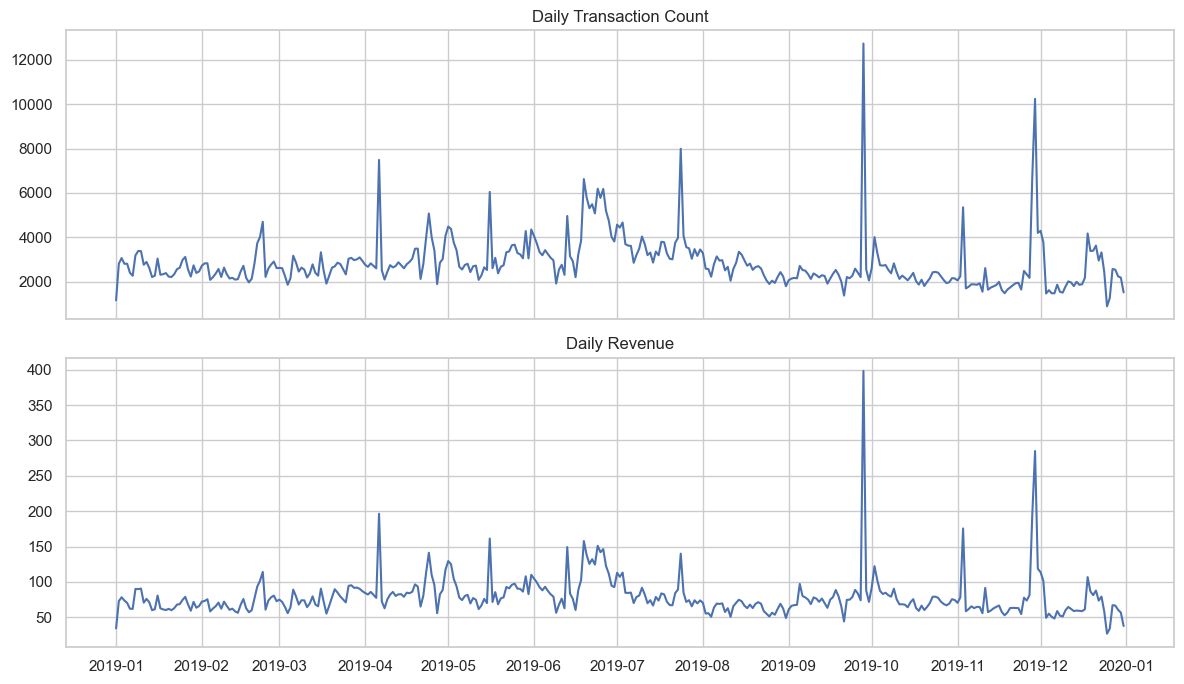

In [8]:

import matplotlib.dates as mdates 

tx = transactions_clean_df.copy()
tx["t_dat"] = pd.to_datetime(tx["t_dat"], errors="coerce")

daily = (
    tx.dropna(subset=["t_dat"])
      .groupby("t_dat")
      .agg(tx_count=("article_id", "count"), revenue=("price", "sum"))
      .reset_index()
      .sort_values("t_dat")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily["t_dat"], daily["tx_count"])
axes[0].set_title("Daily Transaction Count")
axes[1].plot(daily["t_dat"], daily["revenue"])
axes[1].set_title("Daily Revenue")

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()


Summary: from the chart above, you can see that the peak shopping behaviours happened during BFCM, Easter and Christmax

In [9]:
product_perf = (
    transactions_clean_df.groupby("article_id")
    .agg(units_sold=("article_id", "count"), revenue=("price", "sum"))
    .sort_values("units_sold", ascending=False)
)

print("Top 10 articles by units sold")
display(product_perf.head(10))

print("Top 10 articles by revenue")
display(product_perf.sort_values("revenue", ascending=False).head(10))

# Merge with article attributes
product_enriched = transactions_clean_df.merge(
    articles_clean_df[["article_id", "product_group_name", "product_type_name", "department_name"]],
    on="article_id",
    how="left"
)

group_perf = (
    product_enriched.groupby("product_group_name")
    .agg(units_sold=("article_id", "count"), revenue=("price", "sum"))
    .sort_values("units_sold", ascending=False)
)

print("Top product groups")
display(group_perf.head(15))

Top 10 articles by units sold


,units_sold,revenue
article_id,,
706016001,1785,57.383780
706016002,1434,46.656492
372860001,970,12.519051
464297007,841,13.596576
759871002,806,4.000526
706016003,805,26.182271
562245046,796,24.981763
673677002,780,16.991746
156231001,738,4.839492


Top 10 articles by revenue


,units_sold,revenue
article_id,,
706016001,1785,57.383780
706016002,1434,46.656492
568601006,724,35.035440
706016003,805,26.182271
687704001,394,25.251458
562245046,796,24.981763
448509014,605,24.634186
730683001,537,21.847051
399223001,668,21.391847


Top product groups


,units_sold,revenue
product_group_name,,
Garment Upper body,412717,11026.344255
Garment Lower body,230418,7509.388041
Garment Full body,116725,4305.391504
Swimwear,88598,2009.647705
Underwear,80057,1663.307756
Accessories,52036,821.471627
Shoes,25389,997.052016
Socks & Tights,21093,241.632746
Nightwear,11201,277.765813


,recency_days,frequency,monetary
count,458235.000000,458235.000000,458235.000000
mean,152.169489,2.269798,0.063061
std,100.524268,2.143803,0.072366
min,0.000000,1.000000,0.000339
25%,64.000000,1.000000,0.022017
50%,149.000000,1.000000,0.040661
75%,226.000000,3.000000,0.076237
max,364.000000,59.000000,1.961881


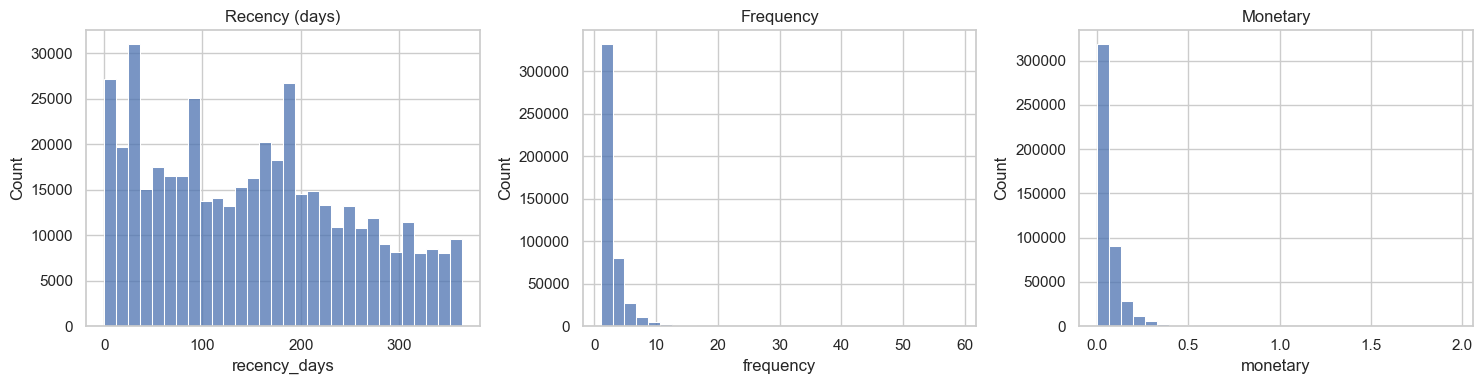

In [10]:
tx = transactions_clean_df.copy()
tx["t_dat"] = pd.to_datetime(tx["t_dat"], errors="coerce")

cust_metrics = (
    tx.groupby("customer_id")
      .agg(
          frequency=("article_id", "count"),
          monetary=("price", "sum"),
          last_purchase=("t_dat", "max")
      )
      .reset_index()
)

max_date = tx["t_dat"].max()
cust_metrics["recency_days"] = (max_date - cust_metrics["last_purchase"]).dt.days

cust_metrics.head()

display(cust_metrics[["recency_days", "frequency", "monetary"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(cust_metrics["recency_days"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Recency (days)")
sns.histplot(cust_metrics["frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency")
sns.histplot(cust_metrics["monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary")
plt.tight_layout()
plt.show()

From the recency table, you can see that many 25% of the cutomers purchased within 64 days while 75% of customers purchased longer than 64 days. Combing this insight with freuqncy,
you can see that most 50% of customers only purchased once. This insight tells us that we need to work on increase purchase frequency.





In [11]:
cust_metrics# Repeat-customer KPI block
# Metrics:
# 1) % of customers that are repeat customers
# 2) Among repeat customers, average repeat volume
# 3) Most popular category in repeat purchases
# 4) Avg time lapse between purchases per repeat customer

tx = transactions_clean_df.copy()
tx["t_dat"] = pd.to_datetime(tx["t_dat"], errors="coerce")

# Keep valid rows
base_tx = tx.dropna(subset=["customer_id", "article_id", "t_dat"]).copy()

# Transactions per customer
cust_tx_count = base_tx.groupby("customer_id").size().rename("tx_count")

# Repeat customer definition: >= 2 transactions
repeat_customers = cust_tx_count[cust_tx_count >= 2].index

# 1) % repeat customers (using customers table as denominator)
n_all_customers = customers_clean_df["customer_id"].nunique()
n_repeat_customers = len(repeat_customers)
pct_repeat_customers = (n_repeat_customers / n_all_customers * 100) if n_all_customers else 0.0

# 2) Avg repeat volume among repeat customers
# repeat volume = transactions beyond first
repeat_volume_per_customer = cust_tx_count.loc[repeat_customers] - 1
avg_repeat_volume = repeat_volume_per_customer.mean() if len(repeat_volume_per_customer) else 0.0

# 3) Most popular category in repeat purchases
# Repeat units at (customer, article) level = max(n - 1, 0)
repeat_units = (
    base_tx.groupby(["customer_id", "article_id"])
    .size()
    .rename("n")
    .reset_index()
)
repeat_units["repeat_units"] = (repeat_units["n"] - 1).clip(lower=0)
repeat_units = repeat_units[repeat_units["repeat_units"] > 0]

category_col = "product_group_name" if "product_group_name" in articles_clean_df.columns else "product_type_name"

repeat_with_cat = repeat_units.merge(
    articles_clean_df[["article_id", category_col]],
    on="article_id",
    how="left"
)

cat_repeat = (
    repeat_with_cat.groupby(category_col, dropna=False)["repeat_units"]
    .sum()
    .sort_values(ascending=False)
)

most_pop_repeat_category = cat_repeat.index[0] if len(cat_repeat) else None
most_pop_repeat_units = int(cat_repeat.iloc[0]) if len(cat_repeat) else 0

# 4) Avg time lapse between purchases per repeat customer
# First compute customer-level mean gap, then average across repeat customers
cust_dates = base_tx.sort_values(["customer_id", "t_dat"]).copy()
cust_dates["gap_days"] = cust_dates.groupby("customer_id")["t_dat"].diff().dt.days

repeat_gap_per_customer = (
    cust_dates[cust_dates["customer_id"].isin(repeat_customers)]
    .groupby("customer_id")["gap_days"]
    .mean()
    .dropna()
)

avg_time_lapse_days = repeat_gap_per_customer.mean() if len(repeat_gap_per_customer) else float("nan")

print("=" * 80)
print("REPEAT CUSTOMER KPIs")
print("=" * 80)
print(f"Total customers (customers table): {n_all_customers:,}")
print(f"Repeat customers (>=2 transactions): {n_repeat_customers:,}")
print(f"% repeat customers: {pct_repeat_customers:.2f}%")
print(f"Avg repeat volume among repeat customers (tx beyond first): {avg_repeat_volume:.2f}")
print(f"Most popular category in repeat purchases ({category_col}): {most_pop_repeat_category} ({most_pop_repeat_units:,} repeat units)")
print(f"Avg time lapse between purchases per repeat customer (days): {avg_time_lapse_days:.2f}")

kpi_table = pd.DataFrame({
    "metric": [
        "% repeat customers",
        "avg repeat volume (among repeat customers)",
        "most popular repeat category",
        "avg time lapse days (repeat customers)",
    ],
    "value": [
        round(pct_repeat_customers, 2),
        round(float(avg_repeat_volume), 2),
        str(most_pop_repeat_category),
        round(float(avg_time_lapse_days), 2) if pd.notna(avg_time_lapse_days) else np.nan,
    ],
})

display(kpi_table)


REPEAT CUSTOMER KPIs
Total customers (customers table): 1,048,575
Repeat customers (>=2 transactions): 228,195
% repeat customers: 21.76%
Avg repeat volume among repeat customers (tx beyond first): 2.55
Most popular category in repeat purchases (product_group_name): Garment Upper body (1,620 repeat units)
Avg time lapse between purchases per repeat customer (days): 64.50


,metric,value
0,% repeat customers,21.76
1,avg repeat volume (among repeat customers),2.55
2,most popular repeat category,Garment Upper body
3,avg time lapse days (repeat customers),64.5


In [12]:
cust_tx = transactions_clean_df.merge(
    customers_clean_df[["customer_id", "age"]], on="customer_id", how="left"
).merge(
    articles_clean_df[["article_id", "product_group_name"]], on="article_id", how="left"
)

cust_tx["age_bin"] = pd.cut(
    cust_tx["age"],
    bins=[0, 24, 34, 44, 54, 64, 120],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

age_group_pref = pd.crosstab(cust_tx["age_bin"], cust_tx["product_group_name"], normalize="index")
print("Age-bin normalized category preference (first 12 columns):")
display(age_group_pref.iloc[:, :12].round(3))

Age-bin normalized category preference (first 12 columns):


product_group_name,Accessories,Bags,Cosmetic,Furniture,Garment Full body,Garment Lower body,Garment Upper body,Garment and Shoe care,Items,Nightwear,Shoes,Socks & Tights
age_bin,,,,,,,,,,,,
<25,0.060,0.0,0.0,0.0,0.100,0.208,0.382,0.0,0.0,0.009,0.020,0.018
25-34,0.052,0.0,0.0,0.0,0.115,0.213,0.385,0.0,0.0,0.011,0.027,0.021
35-44,0.047,0.0,0.0,0.0,0.117,0.234,0.394,0.0,0.0,0.012,0.030,0.022
45-54,0.042,0.0,0.0,0.0,0.112,0.240,0.407,0.0,0.0,0.012,0.020,0.020
55-64,0.042,0.0,0.0,0.0,0.121,0.225,0.439,0.0,0.0,0.011,0.024,0.018
65+,0.046,0.0,0.0,0.0,0.113,0.234,0.490,0.0,0.0,0.012,0.028,0.014


In [13]:
# Extreme price checks
q01 = transactions_clean_df["price"].quantile(0.01)
q99 = transactions_clean_df["price"].quantile(0.99)

print(f"price 1st percentile: {q01:.4f}")
print(f"price 99th percentile: {q99:.4f}")

extreme_low = transactions_clean_df[transactions_clean_df["price"] <= q01]
extreme_high = transactions_clean_df[transactions_clean_df["price"] >= q99]
print("rows in bottom 1% price:", len(extreme_low))
print("rows in top 1% price:", len(extreme_high))

# Daily spike detection with z-score
tx = transactions_clean_df.copy()
tx["t_dat"] = pd.to_datetime(tx["t_dat"], errors="coerce")
daily_stats = (
    tx.dropna(subset=["t_dat"])
      .groupby("t_dat")
      .agg(tx_count=("article_id", "count"), revenue=("price", "sum"))
      .reset_index()
)

daily_stats["z_tx_count"] = (daily_stats["tx_count"] - daily_stats["tx_count"].mean()) / daily_stats["tx_count"].std(ddof=0)
daily_stats["z_revenue"] = (daily_stats["revenue"] - daily_stats["revenue"].mean()) / daily_stats["revenue"].std(ddof=0)

print("Potential tx_count spikes (|z| > 3):")
display(daily_stats.loc[daily_stats["z_tx_count"].abs() > 3, ["t_dat", "tx_count", "z_tx_count"]])

print("Potential revenue spikes (|z| > 3):")
display(daily_stats.loc[daily_stats["z_revenue"].abs() > 3, ["t_dat", "revenue", "z_revenue"]])

price 1st percentile: 0.0034
price 99th percentile: 0.1017
rows in bottom 1% price: 10619
rows in top 1% price: 10519
Potential tx_count spikes (|z| > 3):


,t_dat,tx_count,z_tx_count
95,2019-04-06,7488,3.983767
169,2019-06-19,6625,3.242567
204,2019-07-24,7991,4.415777
270,2019-09-28,12737,8.491951
331,2019-11-28,6716,3.320723
332,2019-11-29,10242,6.349082


Potential revenue spikes (|z| > 3):


,t_dat,revenue,z_revenue
95,2019-04-06,196.435441,3.950354
270,2019-09-28,398.419170,10.754612
306,2019-11-03,175.568932,3.247420
331,2019-11-28,194.817729,3.895857
332,2019-11-29,285.091187,6.936914


In [14]:
articles_clean_df.head(5).to_csv(processed_path / "articles_clean_head5.csv", index=False, header=True)
customers_clean_df.head(5).to_csv(processed_path / "customers_clean_head5.csv", index=False, header=True)
transactions_clean_df.head(5).to_csv(processed_path / "transactions_clean_head5.csv", index=False, header=True)

print("Saved:")
print(" - articles_clean_head5.csv")
print(" - customers_clean_head5.csv")
print(" - transactions_clean_head5.csv")

Saved:
 - articles_clean_head5.csv
 - customers_clean_head5.csv
 - transactions_clean_head5.csv


In [15]:
article_indicator_cols = [
    "product_type_name",
    "product_group_name",
    "graphical_appearance_name",
    "colour_group_name",
    "perceived_colour_value_name",
    "perceived_colour_master_name",
    "department_name",
    "index_code",
    "index_name",
    "section_name",
    "garment_group_name",
]

articles_ind_df = pd.get_dummies(
    articles_clean_df,
    columns=article_indicator_cols,
    dummy_na=True,
    drop_first=False
)


In [16]:
customer_indicator_cols = [
    "FN",
    "Active",
    "club_member_status",
]

customers_ind_df = pd.get_dummies(
    customers_clean_df,
    columns=customer_indicator_cols,
    dummy_na=True,
    drop_first=False
)

In [17]:
# Turn sales_channel_id into indicator variables

transactions_ind_df = pd.get_dummies(
    transactions_clean_df,
    columns=["sales_channel_id"],
    dummy_na=True,
    drop_first=False
)

print("transactions_clean_df:", transactions_clean_df.shape, "->", transactions_ind_df.shape)

transactions_clean_df: (1040101, 5) -> (1040101, 7)
